# Stance Model Comparison (Simple)

This notebook compares stance-detection runs in `data_out/semeval2016_task6_testdata_gold`.

In [177]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    cohen_kappa_score,
)

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 200)


In [178]:
# Configuration
RUNS_ROOT = Path("../data_out/semeval2016_task6_testdata_gold")
OUTPUT_DIR = Path("../data_out/semeval2016_task6_testdata_gold")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["FAVOR", "AGAINST", "NONE"]


def normalize_label(x):
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    mapping = {
        "FAVOR": "FAVOR",
        "AGAINST": "AGAINST",
        "NONE": "NONE",
        "PRO": "FAVOR",
        "SUPPORTS": "FAVOR",
        "NEUTRAL": "NONE",
        "UNRELATED": "NONE",
        "UNCLEAR": "NONE",
    }
    return mapping.get(s)


def read_run_metadata(run_dir: Path):
    """Return metadata for one run folder: backend, model, prompt, run_folder."""
    summary_path = run_dir / "summary.json"
    backend = "unknown"
    model = None
    prompt = None

    if summary_path.exists():
        try:
            data = json.loads(summary_path.read_text())
            cfg = data.get("configuration", {})
            backend = str(cfg.get("llm_backend", "unknown")).lower()
            if backend == "openai":
                model = cfg.get("openai_model")
            else:
                model = cfg.get("vllm_model")
            prompt = cfg.get("stance_prompt_name")
        except Exception:
            pass

    # Fallback parsing from folder name if summary is missing/unreadable
    name = run_dir.name
    if model is None:
        # pattern: ..._semeval2016_task6_testdata_gold_<MODEL>_equal_<PROMPT>
        marker = "semeval2016_task6_testdata_gold_"
        if marker in name and "_equal_" in name:
            tail = name.split(marker, 1)[1]
            model = tail.split("_equal_", 1)[0]
    if prompt is None and "_equal_" in name:
        prompt = name.split("_equal_", 1)[1]

    if model is None:
        model = name
    if prompt is None:
        prompt = "unknown_prompt"

    model_short = str(model).split("/")[-1]
    return {
        "run_folder": name,
        "backend": backend,
        "model": model_short,
        "prompt": str(prompt),
    }


def fleiss_kappa_from_matrix(rating_counts: np.ndarray):
    # rating_counts shape: (N_items, K_categories), each row sums to n_raters
    N, K = rating_counts.shape
    n = rating_counts.sum(axis=1)

    if N == 0:
        return np.nan
    if np.any(n < 2):
        return np.nan
    if len(set(n.tolist())) != 1:
        return np.nan

    n = int(n[0])
    P_i = ((rating_counts ** 2).sum(axis=1) - n) / (n * (n - 1))
    P_bar = P_i.mean()

    p_j = rating_counts.sum(axis=0) / (N * n)
    P_e = (p_j ** 2).sum()

    denom = (1 - P_e)
    if denom == 0:
        return np.nan
    return (P_bar - P_e) / denom


In [179]:
# Step 1: Discover run folders and load files
run_files = sorted(RUNS_ROOT.glob("*/document_assignments.csv"))
if not run_files:
    raise FileNotFoundError(f"No document_assignments.csv files found under {RUNS_ROOT}")

print(f"Found {len(run_files)} run files")

# Step 2: Standardize labels and handle prediction failures
# Policy: Do NOT drop documents for model prediction failures.
# If a prediction is missing/invalid, replace it with "NONE".
# Gold labels are expected to be valid; rows with missing/invalid gold are still dropped (and reported).

system_frames = {}
system_meta = {}
report_rows = []

for path in run_files:
    run_dir = path.parent
    meta = read_run_metadata(run_dir)
    system_id = f"{meta['model']} | {meta['prompt']}"

    # Ensure uniqueness if duplicate model+prompt folders exist
    if system_id in system_frames:
        system_id = f"{system_id} | {meta['run_folder']}"

    df = pd.read_csv(path)
    total_rows = len(df)

    # Normalize labels
    df["gold_norm"] = df["original_stance"].apply(normalize_label)
    df["pred_norm"] = df["predicted_stance"].apply(normalize_label)

    # Count issues before any correction
    invalid_or_missing_gold = int(df["gold_norm"].isna().sum())
    invalid_or_missing_pred = int(df["pred_norm"].isna().sum())

    # Replace missing/invalid predictions with NONE (requested behavior)
    df.loc[df["pred_norm"].isna(), "pred_norm"] = "NONE"
    replaced_pred_with_none = invalid_or_missing_pred

    # Keep evaluation rows: only rows with valid gold
    kept = df[df["gold_norm"].notna()].copy()

    # If duplicated doc_id exists, keep first and report duplicates
    duplicate_doc_ids = int(kept.duplicated(subset=["doc_id"]).sum())
    kept = kept[["doc_id", "gold_norm", "pred_norm"]].drop_duplicates(subset=["doc_id"], keep="first")

    report_rows.append({
        "system": system_id,
        "backend": meta["backend"],
        "model": meta["model"],
        "prompt": meta["prompt"],
        "run_folder": meta["run_folder"],
        "total_rows": total_rows,
        "invalid_or_missing_gold_rows": invalid_or_missing_gold,
        "invalid_or_missing_pred_rows": invalid_or_missing_pred,
        "pred_rows_replaced_with_NONE": replaced_pred_with_none,
        "duplicate_doc_id_rows_removed": duplicate_doc_ids,
        "rows_kept_for_evaluation": len(kept),
    })

    system_frames[system_id] = kept
    system_meta[system_id] = meta

cleaning_report = pd.DataFrame(report_rows).sort_values(["model", "prompt"]).reset_index(drop=True)
print("\nCleaning / replacement report:")
display(cleaning_report)


Found 72 run files

Cleaning / replacement report:


,system,backend,model,prompt,run_folder,total_rows,invalid_or_missing_gold_rows,invalid_or_missing_pred_rows,pred_rows_replaced_with_NONE,duplicate_doc_id_rows_removed,rows_kept_for_evaluation
0,DeepSeek-R1-Distill-Llama-8B | cot,vllm,DeepSeek-R1-Distill-Llama-8B,cot,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0,0,0,0,1249
1,DeepSeek-R1-Distill-Llama-8B | default,vllm,DeepSeek-R1-Distill-Llama-8B,default,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0,0,0,0,1249
2,DeepSeek-R1-Distill-Llama-8B | default_no_labe...,vllm,DeepSeek-R1-Distill-Llama-8B,default_no_label_definitions,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0,0,0,0,1249
3,DeepSeek-R1-Distill-Llama-8B | few_shot,vllm,DeepSeek-R1-Distill-Llama-8B,few_shot,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0,0,0,0,1249
4,DeepSeek-R1-Distill-Llama-8B | question,vllm,DeepSeek-R1-Distill-Llama-8B,question,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0,0,0,0,1249
...,...,...,...,...,...,...,...,...,...,...,...
67,phi-4-mini-instruct | default,vllm,phi-4-mini-instruct,default,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0,0,0,0,1249
68,phi-4-mini-instruct | default_no_label_definit...,vllm,phi-4-mini-instruct,default_no_label_definitions,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0,0,0,0,1249
69,phi-4-mini-instruct | few_shot,vllm,phi-4-mini-instruct,few_shot,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0,0,0,0,1249
70,phi-4-mini-instruct | question,vllm,phi-4-mini-instruct,question,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0,0,0,0,1249


In [180]:
# Step 3: Compute per-system metrics (system = model + prompt)
metric_rows = []

for system_id, dfm in sorted(system_frames.items()):
    meta = system_meta[system_id]
    y_true = dfm["gold_norm"].values
    y_pred = dfm["pred_norm"].values

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, labels=LABELS, average="micro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, labels=LABELS, average="weighted", zero_division=0)

    macro_p, macro_r, _, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS, average="macro", zero_division=0
    )

    p_cls, r_cls, f1_cls, support_cls = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS, average=None, zero_division=0
    )

    row = {
        "system": system_id,
        "backend": meta["backend"],
        "model": meta["model"],
        "prompt": meta["prompt"],
        "run_folder": meta["run_folder"],
        "n_eval": len(dfm),
        "accuracy": acc,
        "macro_f1_unweighted": macro_f1,
        "micro_f1": micro_f1,
        "weighted_f1": weighted_f1,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
    }

    for i, lbl in enumerate(LABELS):
        row[f"precision_{lbl}"] = p_cls[i]
        row[f"recall_{lbl}"] = r_cls[i]
        row[f"f1_{lbl}"] = f1_cls[i]
        row[f"support_{lbl}"] = int(support_cls[i])

    metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows).sort_values("macro_f1_unweighted", ascending=False).reset_index(drop=True)
print("Per-system metrics:")
display(metrics_df)

metrics_out = OUTPUT_DIR / "model_comparison_metrics.csv"
metrics_df.to_csv(metrics_out, index=False)
print(f"Saved: {metrics_out}")


Per-system metrics:


,system,backend,model,prompt,run_folder,n_eval,accuracy,macro_f1_unweighted,micro_f1,weighted_f1,macro_precision,macro_recall,precision_FAVOR,recall_FAVOR,f1_FAVOR,support_FAVOR,precision_AGAINST,recall_AGAINST,f1_AGAINST,support_AGAINST,precision_NONE,recall_NONE,f1_NONE,support_NONE
0,gpt-5.2 | question,openai,gpt-5.2,question,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0.761409,0.748589,0.761409,0.767381,0.734479,0.805235,0.688776,0.888158,0.775862,304,0.951076,0.679720,0.792822,715,0.563584,0.847826,0.677083,230
1,gpt-5.2 | task_definition,openai,gpt-5.2,task_definition,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0.757406,0.746262,0.757406,0.764679,0.736204,0.808953,0.702128,0.868421,0.776471,304,0.965587,0.667133,0.789082,715,0.540897,0.891304,0.673235,230
2,gpt-5-mini | default_no_label_definitions,openai,gpt-5-mini,default_no_label_definitions,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0.752602,0.744299,0.752602,0.758915,0.736670,0.813870,0.699482,0.888158,0.782609,304,0.974630,0.644755,0.776094,715,0.535897,0.908696,0.674194,230
3,gpt-5-mini | few_shot,openai,gpt-5-mini,few_shot,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0.753403,0.743917,0.753403,0.758827,0.733463,0.809900,0.690773,0.911184,0.785816,304,0.964657,0.648951,0.775920,715,0.544959,0.869565,0.670017,230
4,gpt-5-mini | task_definition,openai,gpt-5-mini,task_definition,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0.749400,0.740375,0.749400,0.756432,0.733673,0.809131,0.697128,0.878289,0.777293,304,0.974630,0.644755,0.776094,715,0.529262,0.904348,0.667737,230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Qwen3-1.7B | default_no_label_definitions,vllm,Qwen3-1.7B,default_no_label_definitions,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0.370697,0.369998,0.370697,0.314638,0.488864,0.515786,0.345324,0.631579,0.446512,304,0.809091,0.124476,0.215758,715,0.312178,0.791304,0.447724,230
68,Qwen3-1.7B | question,vllm,Qwen3-1.7B,question,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0.360288,0.363392,0.360288,0.340439,0.459463,0.477477,0.404762,0.391447,0.397993,304,0.718085,0.188811,0.299003,715,0.255541,0.852174,0.393180,230
69,Qwen3-1.7B | default,vllm,Qwen3-1.7B,default,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0.345076,0.346538,0.345076,0.297545,0.486623,0.490275,0.400000,0.473684,0.433735,304,0.801887,0.118881,0.207065,715,0.257982,0.878261,0.398815,230
70,Qwen3-1.7B | task_definition,vllm,Qwen3-1.7B,task_definition,GenAIStanceOneShot_1249_semeval2016_task6_test...,1249,0.293835,0.289862,0.293835,0.250913,0.482202,0.430561,0.450000,0.266447,0.334711,304,0.778947,0.103497,0.182716,715,0.217659,0.921739,0.352159,230


Saved: ../data_out/semeval2016_task6_testdata_gold/model_comparison_metrics.csv


In [181]:
# Step 4: Easier comparison views (model x prompt)
core_cols = [
    "system", "backend", "model", "prompt", "n_eval",
    "accuracy", "macro_f1_unweighted", "micro_f1", "weighted_f1",
    "macro_precision", "macro_recall"
]
metrics_core = metrics_df[core_cols].copy().sort_values(["model", "prompt"]).reset_index(drop=True)

print("Long format metrics (model + prompt):")
display(metrics_core)

pivot_macro = metrics_core.pivot(index="model", columns="prompt", values="macro_f1_unweighted")
pivot_acc = metrics_core.pivot(index="model", columns="prompt", values="accuracy")

print("\nMacro-F1 pivot (rows=model, cols=prompt):")
display(pivot_macro)

print("\nAccuracy pivot (rows=model, cols=prompt):")
display(pivot_acc)

# Prompt-level summary across models
prompt_summary = (
    metrics_core.groupby("prompt", as_index=False)
    .agg(
        runs=("model", "count"),
        macro_f1_mean=("macro_f1_unweighted", "mean"),
        macro_f1_std=("macro_f1_unweighted", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
    )
    .sort_values("macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)
print("\nPrompt-level summary:")
display(prompt_summary)

# Gain vs default per model
default_df = metrics_core[metrics_core["prompt"] == "default"][["model", "macro_f1_unweighted", "accuracy"]].rename(
    columns={
        "macro_f1_unweighted": "macro_f1_default",
        "accuracy": "accuracy_default",
    }
)

gain_df = metrics_core.merge(default_df, on="model", how="left")
gain_df["macro_f1_gain_vs_default"] = gain_df["macro_f1_unweighted"] - gain_df["macro_f1_default"]
gain_df["accuracy_gain_vs_default"] = gain_df["accuracy"] - gain_df["accuracy_default"]

print("\nGain vs default (per model/prompt):")
display(gain_df.sort_values(["model", "prompt"]).reset_index(drop=True))

best_prompt_per_model = (
    metrics_core.sort_values(["model", "macro_f1_unweighted"], ascending=[True, False])
    .groupby("model", as_index=False)
    .first()[["model", "prompt", "macro_f1_unweighted", "accuracy"]]
    .rename(columns={"prompt": "best_prompt"})
)
print("\nBest prompt per model (by macro-F1):")
display(best_prompt_per_model)

pivot_macro.to_csv(OUTPUT_DIR / "pivot_macro_f1_by_model_prompt.csv")
pivot_acc.to_csv(OUTPUT_DIR / "pivot_accuracy_by_model_prompt.csv")
prompt_summary.to_csv(OUTPUT_DIR / "prompt_summary_metrics.csv", index=False)
gain_df.to_csv(OUTPUT_DIR / "gain_vs_default_metrics.csv", index=False)
best_prompt_per_model.to_csv(OUTPUT_DIR / "best_prompt_per_model.csv", index=False)
print("Saved comparison CSVs (pivot + summary + gain + best prompt).")


Long format metrics (model + prompt):


,system,backend,model,prompt,n_eval,accuracy,macro_f1_unweighted,micro_f1,weighted_f1,macro_precision,macro_recall
0,DeepSeek-R1-Distill-Llama-8B | cot,vllm,DeepSeek-R1-Distill-Llama-8B,cot,1249,0.577262,0.574181,0.577262,0.588397,0.600070,0.645572
1,DeepSeek-R1-Distill-Llama-8B | default,vllm,DeepSeek-R1-Distill-Llama-8B,default,1249,0.539632,0.546011,0.539632,0.553299,0.617693,0.632076
2,DeepSeek-R1-Distill-Llama-8B | default_no_labe...,vllm,DeepSeek-R1-Distill-Llama-8B,default_no_label_definitions,1249,0.594075,0.584589,0.594075,0.604570,0.595437,0.646717
3,DeepSeek-R1-Distill-Llama-8B | few_shot,vllm,DeepSeek-R1-Distill-Llama-8B,few_shot,1249,0.560448,0.565661,0.560448,0.574955,0.624151,0.646163
4,DeepSeek-R1-Distill-Llama-8B | question,vllm,DeepSeek-R1-Distill-Llama-8B,question,1249,0.566053,0.567472,0.566053,0.581139,0.610197,0.640757
...,...,...,...,...,...,...,...,...,...,...,...
67,phi-4-mini-instruct | default,vllm,phi-4-mini-instruct,default,1249,0.556445,0.556369,0.556445,0.572192,0.620764,0.632082
68,phi-4-mini-instruct | default_no_label_definit...,vllm,phi-4-mini-instruct,default_no_label_definitions,1249,0.602882,0.590840,0.602882,0.617586,0.622198,0.645561
69,phi-4-mini-instruct | few_shot,vllm,phi-4-mini-instruct,few_shot,1249,0.546837,0.522646,0.546837,0.557516,0.522122,0.558434
70,phi-4-mini-instruct | question,vllm,phi-4-mini-instruct,question,1249,0.616493,0.571775,0.616493,0.621997,0.566428,0.582705



Macro-F1 pivot (rows=model, cols=prompt):


prompt,cot,default,default_no_label_definitions,few_shot,question,task_definition
model,,,,,,
DeepSeek-R1-Distill-Llama-8B,0.574181,0.546011,0.584589,0.565661,0.567472,0.536203
DeepSeek-R1-Distill-Qwen-14B,0.652429,0.612363,0.622837,0.633970,0.641310,0.606183
Llama-3.1-8B-Instruct,0.585246,0.609252,0.582121,0.474403,0.593201,0.581653
Qwen3-1.7B,0.465054,0.346538,0.369998,0.258685,0.363392,0.289862
Qwen3-14B,0.618679,0.558809,0.585627,0.607964,0.627720,0.569295
Qwen3-4B,0.605148,0.588066,0.595846,0.617881,0.653352,0.606897
Qwen3-4B-Instruct-2507,0.638891,0.581973,0.600731,0.628380,0.635622,0.598754
Qwen3-8B,0.577409,0.528783,0.577730,0.640849,0.615678,0.580300
gpt-5-mini,0.721543,0.735110,0.744299,0.743917,0.722269,0.740375



Accuracy pivot (rows=model, cols=prompt):


...


Gain vs default (per model/prompt):


,system,backend,model,prompt,n_eval,accuracy,macro_f1_unweighted,micro_f1,weighted_f1,macro_precision,macro_recall,macro_f1_default,accuracy_default,macro_f1_gain_vs_default,accuracy_gain_vs_default
0,DeepSeek-R1-Distill-Llama-8B | cot,vllm,DeepSeek-R1-Distill-Llama-8B,cot,1249,0.577262,0.574181,0.577262,0.588397,0.600070,0.645572,0.546011,0.539632,0.028170,0.037630
1,DeepSeek-R1-Distill-Llama-8B | default,vllm,DeepSeek-R1-Distill-Llama-8B,default,1249,0.539632,0.546011,0.539632,0.553299,0.617693,0.632076,0.546011,0.539632,0.000000,0.000000
2,DeepSeek-R1-Distill-Llama-8B | default_no_labe...,vllm,DeepSeek-R1-Distill-Llama-8B,default_no_label_definitions,1249,0.594075,0.584589,0.594075,0.604570,0.595437,0.646717,0.546011,0.539632,0.038578,0.054444
3,DeepSeek-R1-Distill-Llama-8B | few_shot,vllm,DeepSeek-R1-Distill-Llama-8B,few_shot,1249,0.560448,0.565661,0.560448,0.574955,0.624151,0.646163,0.546011,0.539632,0.019649,0.020817
4,DeepSeek-R1-Distill-Llama-8B | question,vllm,DeepSeek-R1-Distill-Llama-8B,question,1249,0.566053,0.567472,0.566053,0.581139,0.610197,0.640757,0.546011,0.539632,0.021461,0.026421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,phi-4-mini-instruct | default,vllm,phi-4-mini-instruct,default,1249,0.556445,0.556369,0.556445,0.572192,0.620764,0.632082,0.556369,0.556445,0.000000,0.000000
68,phi-4-mini-instruct | default_no_label_definit...,vllm,phi-4-mini-instruct,default_no_label_definitions,1249,0.602882,0.590840,0.602882,0.617586,0.622198,0.645561,0.556369,0.556445,0.034471,0.046437
69,phi-4-mini-instruct | few_shot,vllm,phi-4-mini-instruct,few_shot,1249,0.546837,0.522646,0.546837,0.557516,0.522122,0.558434,0.556369,0.556445,-0.033723,-0.009608
70,phi-4-mini-instruct | question,vllm,phi-4-mini-instruct,question,1249,0.616493,0.571775,0.616493,0.621997,0.566428,0.582705,0.556369,0.556445,0.015406,0.060048



Best prompt per model (by macro-F1):


,model,best_prompt,macro_f1_unweighted,accuracy
0,DeepSeek-R1-Distill-Llama-8B,default_no_label_definitions,0.584589,0.594075
1,DeepSeek-R1-Distill-Qwen-14B,cot,0.652429,0.654123
2,Llama-3.1-8B-Instruct,default,0.609252,0.634107
3,Qwen3-1.7B,cot,0.465054,0.461169
4,Qwen3-14B,question,0.627720,0.626902
5,Qwen3-4B,question,0.653352,0.663731
6,Qwen3-4B-Instruct-2507,cot,0.638891,0.655725
7,Qwen3-8B,few_shot,0.640849,0.646117
8,gpt-5-mini,default_no_label_definitions,0.744299,0.752602
9,gpt-5.2,question,0.748589,0.761409


Saved comparison CSVs (pivot + summary + gain + best prompt).


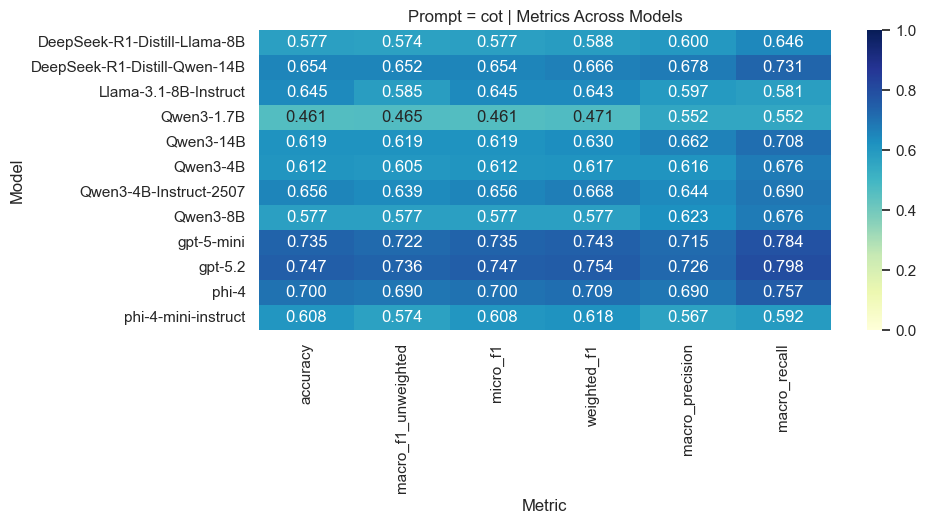

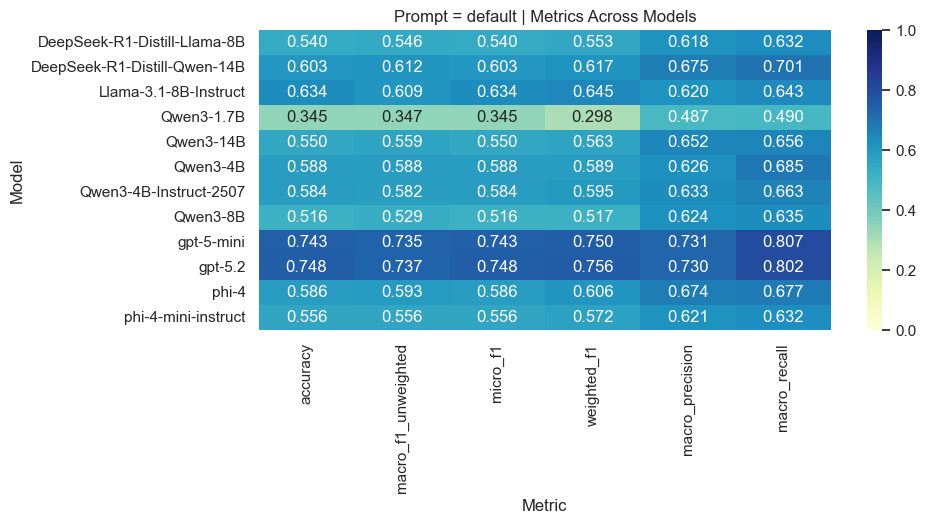

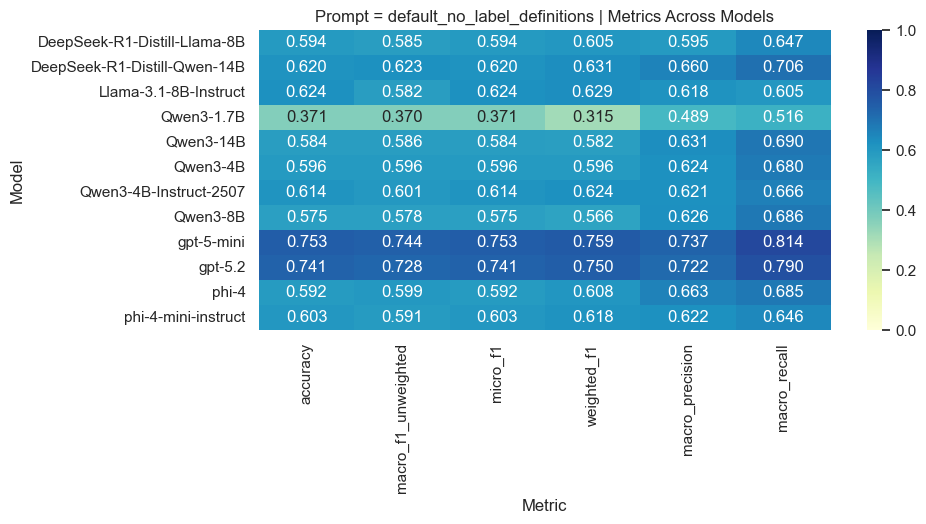

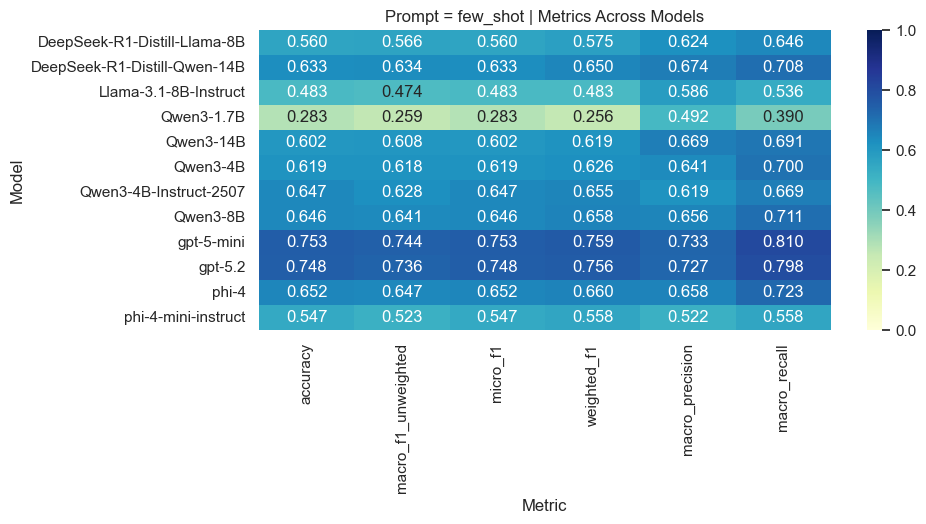

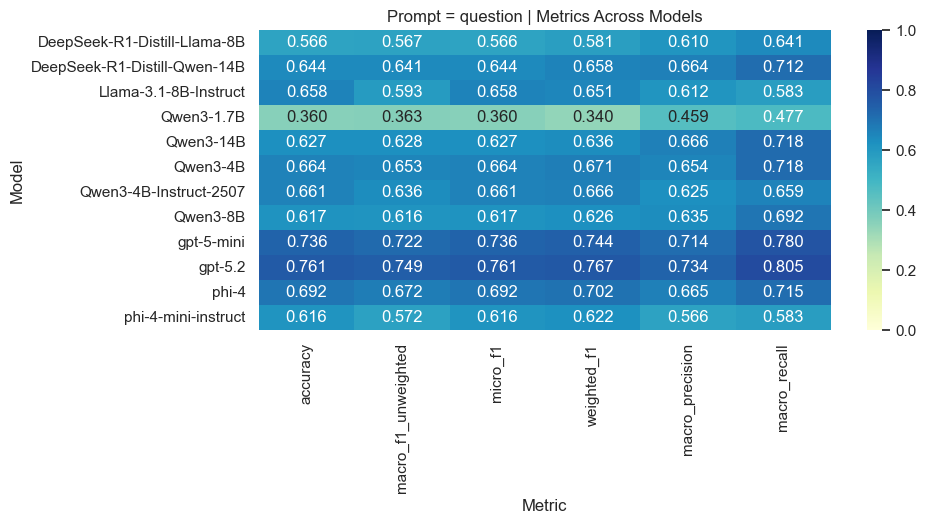

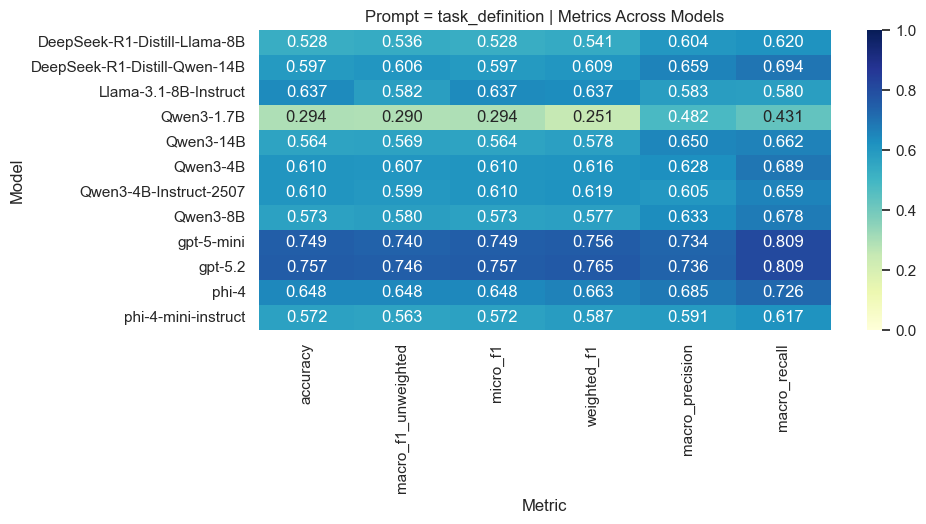

In [182]:
# Step 5: Separate heatmaps per prompt (across all models)
heatmap_metrics = [
    "accuracy",
    "macro_f1_unweighted",
    "micro_f1",
    "weighted_f1",
    "macro_precision",
    "macro_recall",
]

prompt_order = sorted(metrics_df["prompt"].dropna().unique().tolist())

for prompt_name in prompt_order:
    sub = metrics_df[metrics_df["prompt"] == prompt_name].copy()
    sub = sub.sort_values("model")

    # model x metric matrix for this prompt
    hm = sub.set_index("model")[heatmap_metrics]

    plt.figure(figsize=(10, max(4, 0.45 * len(hm))))
    sns.heatmap(hm, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
    plt.title(f"Prompt = {prompt_name} | Metrics Across Models")
    plt.xlabel("Metric")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()


In [183]:
# Build aligned prediction matrix for agreement analysis
# Note: agreement is computed across systems (model + prompt), on common doc_ids.
pred_matrix = None

for system_id, dfm in sorted(system_frames.items()):
    s_pred = dfm.set_index("doc_id")["pred_norm"].rename(system_id)

    if pred_matrix is None:
        pred_matrix = s_pred.to_frame()
    else:
        pred_matrix = pred_matrix.join(s_pred, how="inner")

# Safety: drop missing values if any remain
pred_matrix = pred_matrix.dropna()
common_doc_ids = pred_matrix.index

print(f"Systems in agreement analysis: {pred_matrix.shape[1]}")
print(f"Common doc_ids used for agreement: {pred_matrix.shape[0]}")


Systems in agreement analysis: 72
Common doc_ids used for agreement: 1249


In [184]:
# Raw agreement matrix + Fleiss' kappa + all-model consensus rate
models = list(pred_matrix.columns)

agreement = pd.DataFrame(index=models, columns=models, dtype=float)
for m1 in models:
    for m2 in models:
        agreement.loc[m1, m2] = (pred_matrix[m1] == pred_matrix[m2]).mean()

# Fleiss' kappa across all models
rating_counts = []
for _, row in pred_matrix.iterrows():
    counts = [(row == lbl).sum() for lbl in LABELS]
    rating_counts.append(counts)
rating_counts = np.array(rating_counts, dtype=int)

fleiss_kappa = fleiss_kappa_from_matrix(rating_counts)
consensus_rate = (pred_matrix.nunique(axis=1) == 1).mean()

print(f"Fleiss' kappa (all models): {fleiss_kappa:.4f}")
print(f"All-model consensus rate: {consensus_rate:.4f}")

a_out = OUTPUT_DIR / "pairwise_raw_agreement.csv"
agreement.to_csv(a_out)
print(f"Saved: {a_out}")


Fleiss' kappa (all models): 0.4958
All-model consensus rate: 0.0424
Saved: ../data_out/semeval2016_task6_testdata_gold/pairwise_raw_agreement.csv


In [185]:
# Pairwise Cohen's kappa matrix (chance-corrected pair agreement)

models = list(pred_matrix.columns)
kappa_matrix = pd.DataFrame(index=models, columns=models, dtype=float)

for m1 in models:
    for m2 in models:
        if m1 == m2:
            kappa_matrix.loc[m1, m2] = 1.0
        else:
            kappa_matrix.loc[m1, m2] = cohen_kappa_score(pred_matrix[m1], pred_matrix[m2], labels=LABELS)

print("Pairwise Cohen's kappa matrix:")
display(kappa_matrix)

kappa_out = OUTPUT_DIR / "pairwise_cohens_kappa.csv"
kappa_matrix.to_csv(kappa_out)
print(f"Saved: {kappa_out}")

# Ranked model pairs by Cohen's kappa
kappa_pairs = []
for i, m1 in enumerate(models):
    for j, m2 in enumerate(models):
        if j <= i:
            continue
        kappa_pairs.append({
            "model_1": m1,
            "model_2": m2,
            "cohens_kappa": float(kappa_matrix.loc[m1, m2]),
        })

kappa_pairs_df = pd.DataFrame(kappa_pairs).sort_values("cohens_kappa", ascending=False).reset_index(drop=True)
print("Top model pairs by Cohen's kappa:")
display(kappa_pairs_df)

kappa_pairs_out = OUTPUT_DIR / "model_pair_cohens_kappa_ranked.csv"
kappa_pairs_df.to_csv(kappa_pairs_out, index=False)
print(f"Saved: {kappa_pairs_out}")


Pairwise Cohen's kappa matrix:


,DeepSeek-R1-Distill-Llama-8B | cot,DeepSeek-R1-Distill-Llama-8B | default,DeepSeek-R1-Distill-Llama-8B | default_no_label_definitions,DeepSeek-R1-Distill-Llama-8B | few_shot,DeepSeek-R1-Distill-Llama-8B | question,DeepSeek-R1-Distill-Llama-8B | task_definition,DeepSeek-R1-Distill-Qwen-14B | cot,DeepSeek-R1-Distill-Qwen-14B | default,DeepSeek-R1-Distill-Qwen-14B | default_no_label_definitions,DeepSeek-R1-Distill-Qwen-14B | few_shot,DeepSeek-R1-Distill-Qwen-14B | question,DeepSeek-R1-Distill-Qwen-14B | task_definition,Llama-3.1-8B-Instruct | cot,Llama-3.1-8B-Instruct | default,Llama-3.1-8B-Instruct | default_no_label_definitions,Llama-3.1-8B-Instruct | few_shot,Llama-3.1-8B-Instruct | question,Llama-3.1-8B-Instruct | task_definition,Qwen3-1.7B | cot,Qwen3-1.7B | default,Qwen3-1.7B | default_no_label_definitions,Qwen3-1.7B | few_shot,Qwen3-1.7B | question,Qwen3-1.7B | task_definition,Qwen3-14B | cot,Qwen3-14B | default,Qwen3-14B | default_no_label_definitions,Qwen3-14B | few_shot,Qwen3-14B | question,Qwen3-14B | task_definition,Qwen3-4B | cot,Qwen3-4B | default,Qwen3-4B | default_no_label_definitions,Qwen3-4B | few_shot,Qwen3-4B | question,Qwen3-4B | task_definition,Qwen3-4B-Instruct-2507 | cot,Qwen3-4B-Instruct-2507 | default,Qwen3-4B-Instruct-2507 | default_no_label_definitions,Qwen3-4B-Instruct-2507 | few_shot,Qwen3-4B-Instruct-2507 | question,Qwen3-4B-Instruct-2507 | task_definition,Qwen3-8B | cot,Qwen3-8B | default,Qwen3-8B | default_no_label_definitions,Qwen3-8B | few_shot,Qwen3-8B | question,Qwen3-8B | task_definition,gpt-5-mini | cot,gpt-5-mini | default,gpt-5-mini | default_no_label_definitions,gpt-5-mini | few_shot,gpt-5-mini | question,gpt-5-mini | task_definition,gpt-5.2 | cot,gpt-5.2 | default,gpt-5.2 | default_no_label_definitions,gpt-5.2 | few_shot,gpt-5.2 | question,gpt-5.2 | task_definition,phi-4 | cot,phi-4 | default,phi-4 | default_no_label_definitions,phi-4 | few_shot,phi-4 | question,phi-4 | task_definition,phi-4-mini-instruct | cot,phi-4-mini-instruct | default,phi-4-mini-instruct | default_no_label_definitions,phi-4-mini-instruct | few_shot,phi-4-mini-instruct | question,phi-4-mini-instruct | task_definition
DeepSeek-R1-Distill-Llama-8B | cot,1.000000,0.575271,0.550376,0.532165,0.571825,0.526237,0.528067,0.544659,0.554269,0.531945,0.541836,0.533417,0.368903,0.452164,0.413362,0.325495,0.333028,0.383674,0.392037,0.241398,0.242005,0.169654,0.260544,0.208258,0.528251,0.506939,0.492799,0.542773,0.536180,0.494787,0.501514,0.503950,0.450256,0.542352,0.521380,0.522743,0.532901,0.462940,0.468527,0.479439,0.449063,0.471339,0.483176,0.504641,0.494768,0.528931,0.538805,0.515609,0.473215,0.497413,0.506725,0.509142,0.495554,0.492196,0.475223,0.486065,0.486297,0.486957,0.482900,0.489415,0.517431,0.471222,0.485211,0.539419,0.501841,0.507591,0.448021,0.483405,0.476376,0.405519,0.357082,0.476215
DeepSeek-R1-Distill-Llama-8B | default,0.575271,1.000000,0.550603,0.582013,0.554153,0.606746,0.536572,0.589274,0.565182,0.546057,0.555046,0.560261,0.339827,0.429710,0.394762,0.275514,0.279270,0.329042,0.459427,0.276546,0.278987,0.188922,0.310980,0.245691,0.547748,0.567618,0.512989,0.581859,0.572108,0.553153,0.480564,0.517051,0.477129,0.542335,0.512794,0.555058,0.520712,0.510247,0.490485,0.469616,0.426094,0.480524,0.495970,0.559539,0.485232,0.548801,0.530074,0.575011,0.467751,0.509965,0.515023,0.502049,0.480312,0.503808,0.476784,0.478173,0.476435,0.478481,0.454683,0.463173,0.505270,0.530161,0.522042,0.482134,0.459326,0.515800,0.375476,0.528744,0.487023,0.367544,0.349284,0.481831
DeepSeek-R1-Distill-Llama-8B | default_no_label_definitions,0.550376,0.550603,1.000000,0.532565,0.536652,0.534970,0.514057,0.524237,0.535544,0.543801,0.535724,0.523183,0.397061,0.450285,0.425949,0.335025,0.355962,0.402322,0.377640,0.229494,0.250305,0.140842,0.265360,0.183302,0.507861,0.472108,0.496668,0.517070,0.530806,0.483093,0.536878,0.508404,0.498773,0.550389,0.555813,0.534926,0.509384,0.473429,0.482400,0.500303,0.464413,0.474414,0.507480,0.466316,0.48748

Saved: ../data_out/semeval2016_task6_testdata_gold/pairwise_cohens_kappa.csv
Top model pairs by Cohen's kappa:


,model_1,model_2,cohens_kappa
0,gpt-5.2 | default,gpt-5.2 | task_definition,0.918936
1,gpt-5.2 | default,gpt-5.2 | default_no_label_definitions,0.908088
2,gpt-5.2 | default_no_label_definitions,gpt-5.2 | task_definition,0.906785
3,gpt-5-mini | default,gpt-5-mini | default_no_label_definitions,0.903542
4,gpt-5-mini | default,gpt-5-mini | task_definition,0.898711
...,...,...,...
2551,Qwen3-1.7B | few_shot,Qwen3-4B | default_no_label_definitions,0.110106
2552,Qwen3-1.7B | few_shot,gpt-5-mini | cot,0.103889
2553,Llama-3.1-8B-Instruct | few_shot,Qwen3-1.7B | task_definition,0.103295
2554,Llama-3.1-8B-Instruct | question,Qwen3-1.7B | few_shot,0.099711


Saved: ../data_out/semeval2016_task6_testdata_gold/model_pair_cohens_kappa_ranked.csv


In [186]:
# Model pairs ranked by raw agreement (descending)

pair_rows = []
models = list(agreement.index)
for i, m1 in enumerate(models):
    for j, m2 in enumerate(models):
        if j <= i:
            continue
        pair_rows.append({
            "model_1": m1,
            "model_2": m2,
            "raw_agreement": float(agreement.loc[m1, m2]),
        })

pairs_df = pd.DataFrame(pair_rows).sort_values("raw_agreement", ascending=False).reset_index(drop=True)
print("Top model pairs by raw agreement:")
display(pairs_df)

pairs_out = OUTPUT_DIR / "model_pair_agreement_ranked.csv"
pairs_df.to_csv(pairs_out, index=False)
print(f"Saved: {pairs_out}")


Top model pairs by raw agreement:


,model_1,model_2,raw_agreement
0,gpt-5.2 | default,gpt-5.2 | task_definition,0.946357
1,gpt-5.2 | default,gpt-5.2 | default_no_label_definitions,0.939151
2,gpt-5.2 | default_no_label_definitions,gpt-5.2 | task_definition,0.938351
3,gpt-5-mini | default,gpt-5-mini | default_no_label_definitions,0.935949
4,gpt-5-mini | default,gpt-5-mini | task_definition,0.932746
...,...,...,...
2551,Llama-3.1-8B-Instruct | question,Qwen3-1.7B | default,0.323459
2552,Llama-3.1-8B-Instruct | few_shot,Qwen3-1.7B | task_definition,0.289031
2553,Llama-3.1-8B-Instruct | question,Qwen3-1.7B | task_definition,0.282626
2554,Llama-3.1-8B-Instruct | question,Qwen3-1.7B | few_shot,0.278623


Saved: ../data_out/semeval2016_task6_testdata_gold/model_pair_agreement_ranked.csv



Prompt: cot | models=12 | common_docs=1249


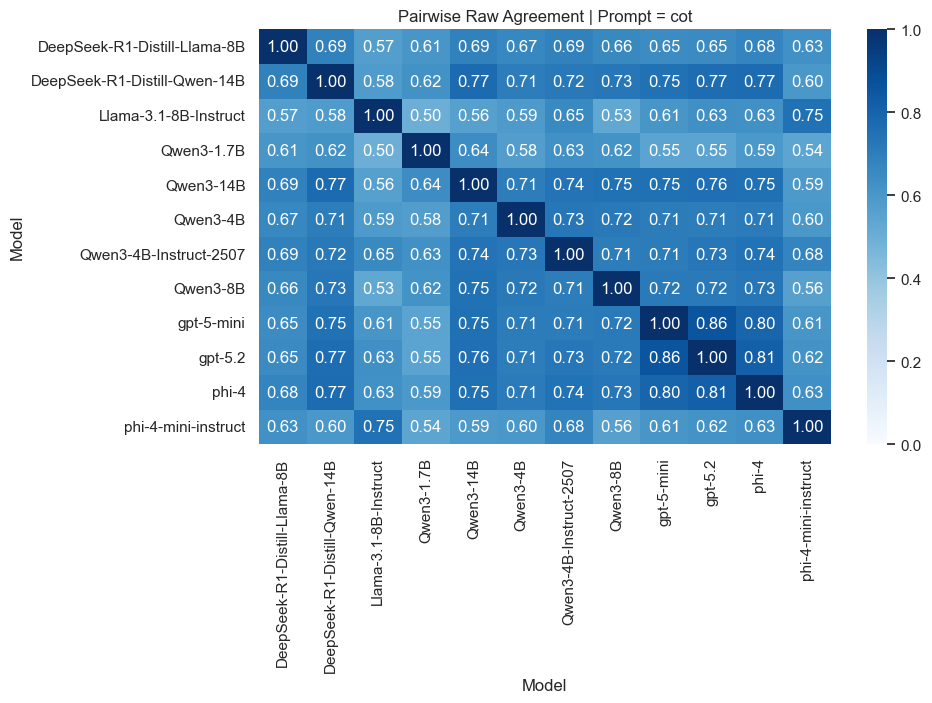

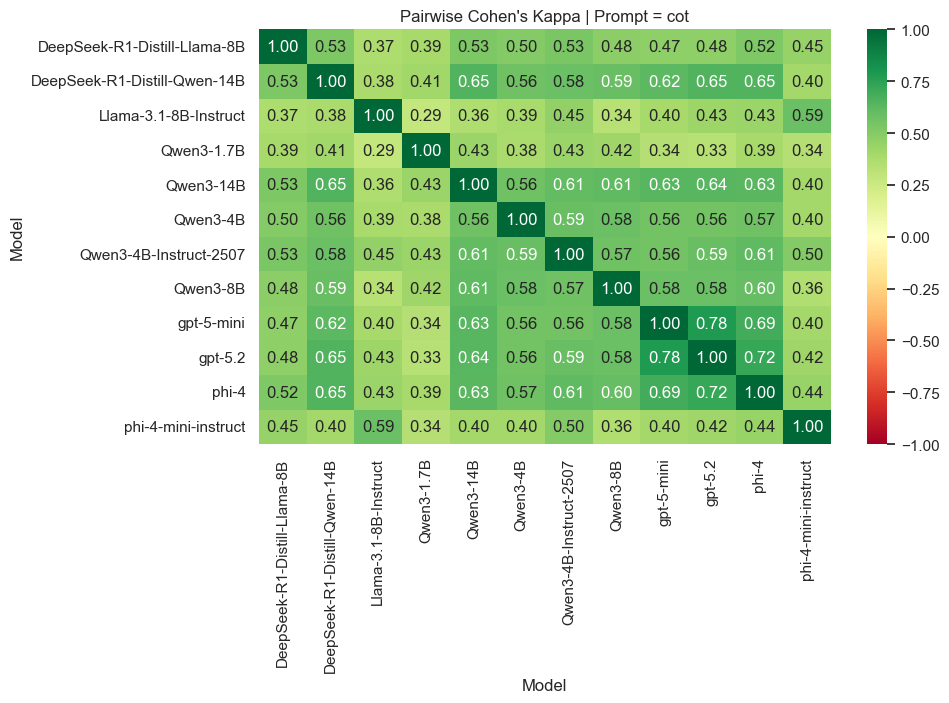


Prompt: default | models=12 | common_docs=1249


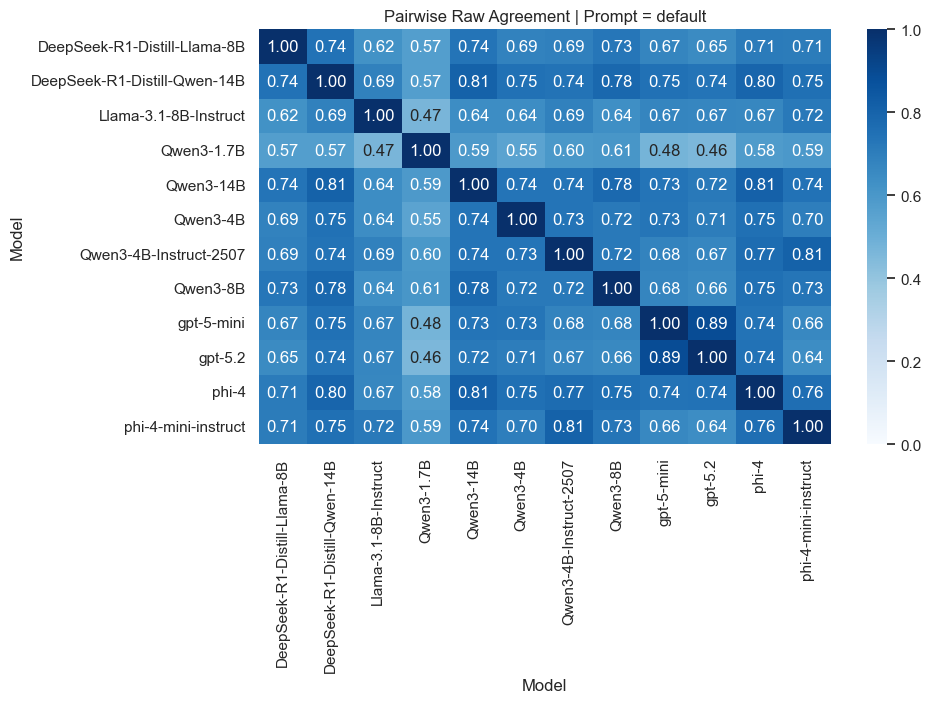

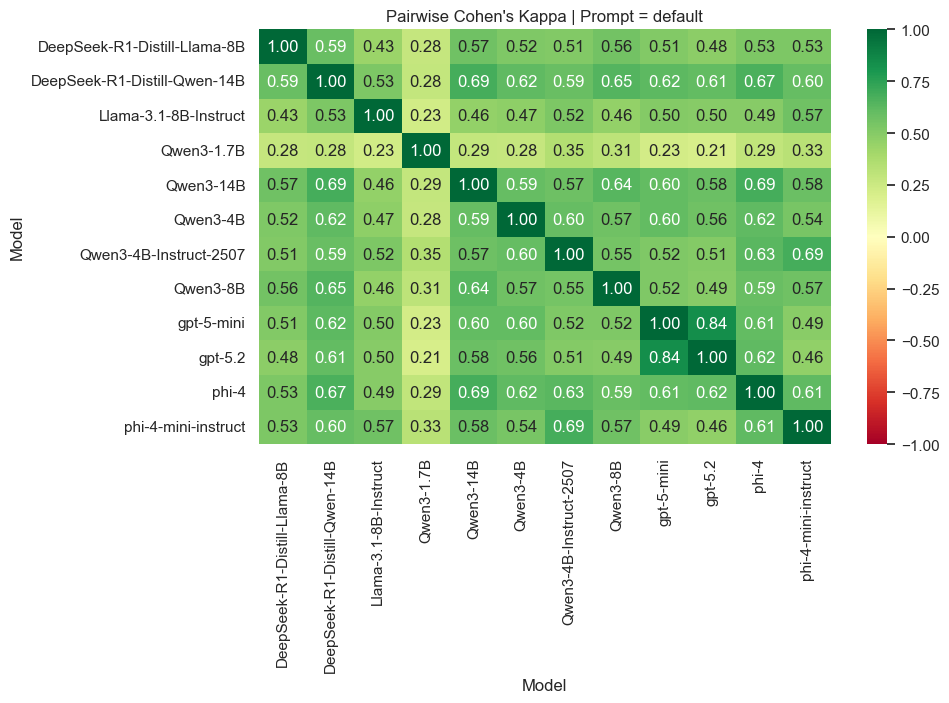


Prompt: default_no_label_definitions | models=12 | common_docs=1249


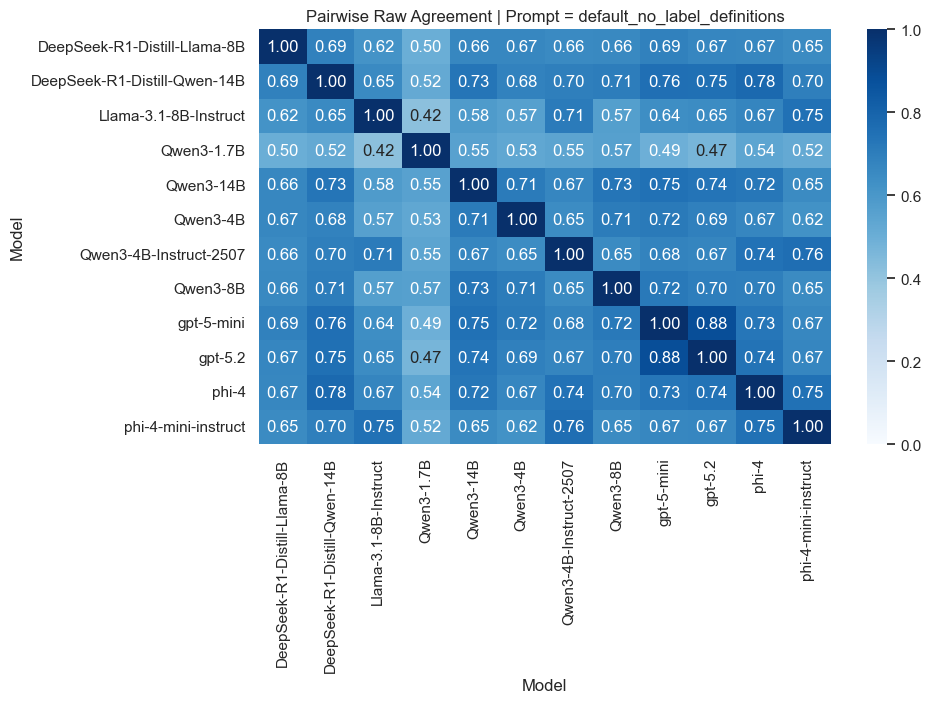

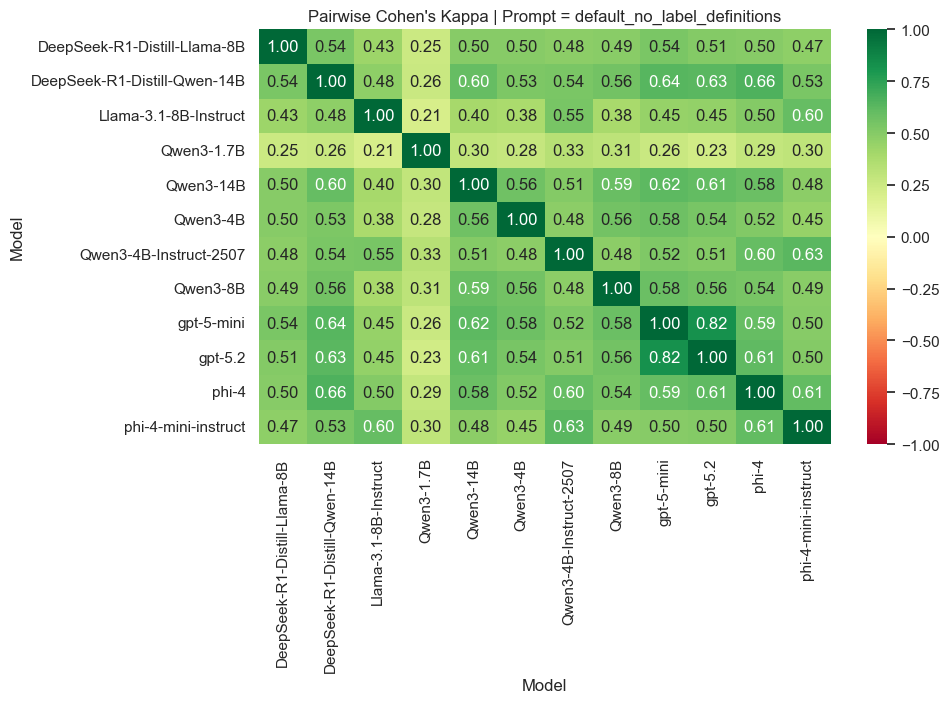


Prompt: few_shot | models=12 | common_docs=1249


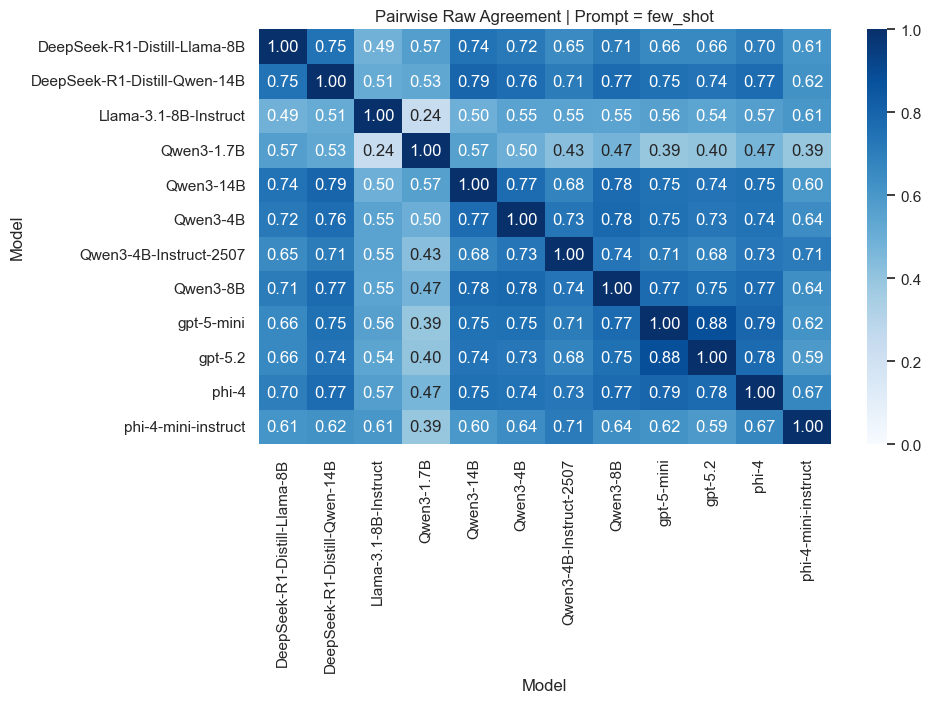

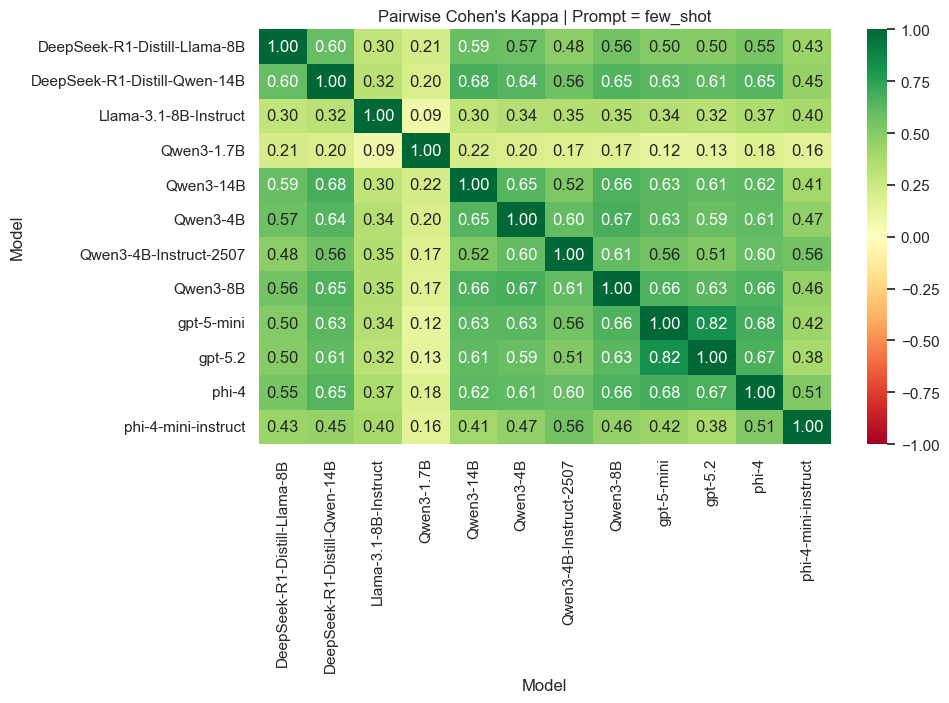


Prompt: question | models=12 | common_docs=1249


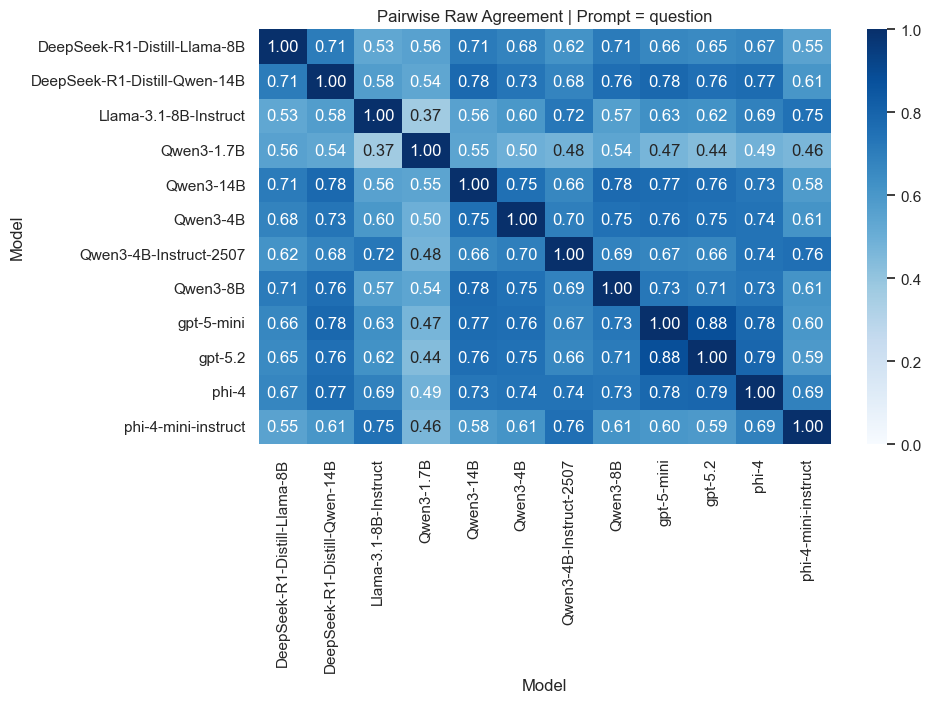

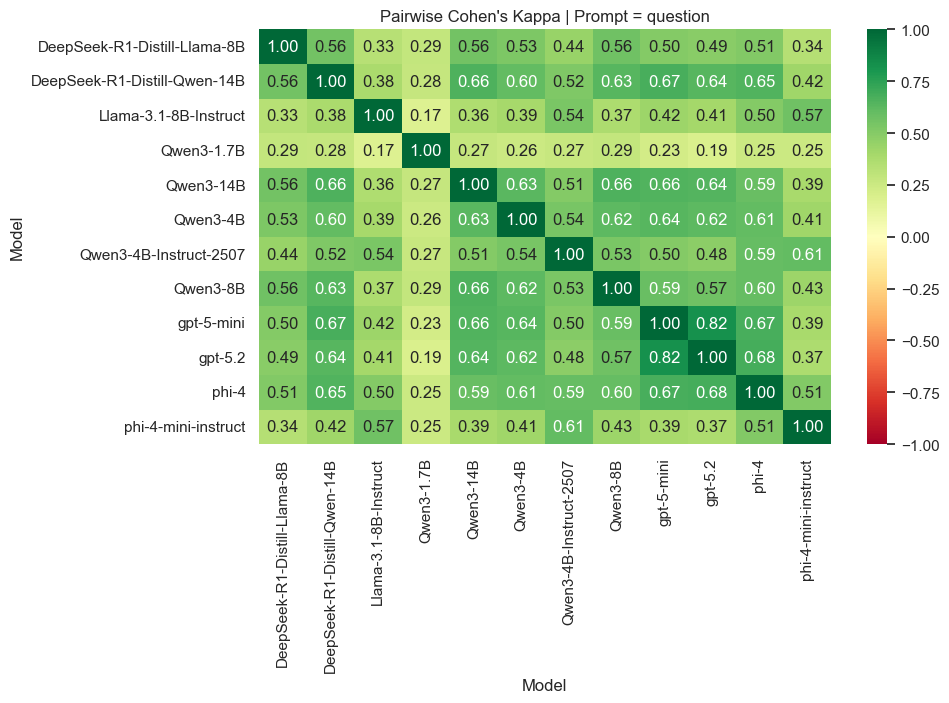


Prompt: task_definition | models=12 | common_docs=1249


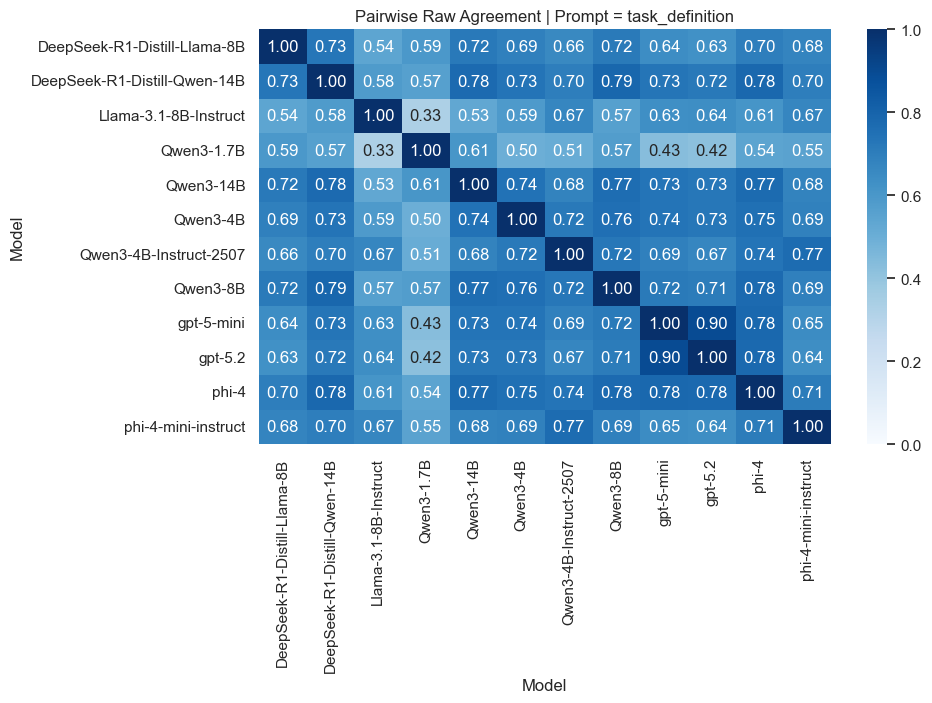

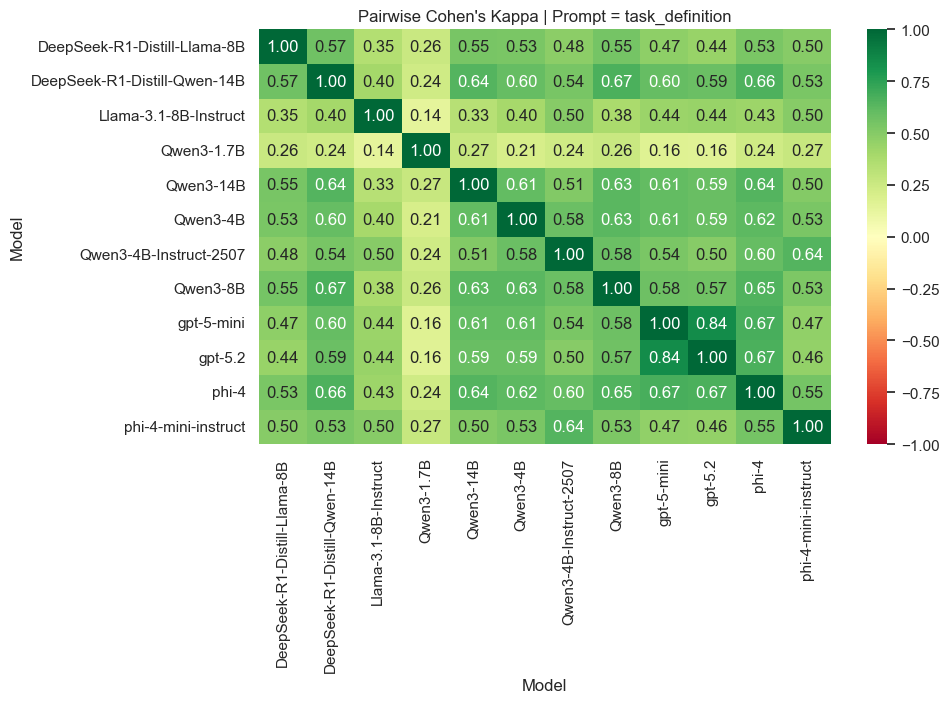

In [187]:
# Heatmaps per prompt: pairwise raw agreement + pairwise Cohen's kappa (across models)
prompt_to_model_preds = {}

for system_id, dfm in system_frames.items():
    meta = system_meta[system_id]
    prompt = meta["prompt"]
    model = meta["model"]

    prompt_to_model_preds.setdefault(prompt, {})
    # If duplicate model exists for same prompt, keep first for clean matrices
    if model not in prompt_to_model_preds[prompt]:
        prompt_to_model_preds[prompt][model] = dfm.set_index("doc_id")["pred_norm"]

for prompt_name in sorted(prompt_to_model_preds):
    model_series = prompt_to_model_preds[prompt_name]

    # Need at least 2 models for pairwise agreement
    if len(model_series) < 2:
        print(f"Skipping prompt '{prompt_name}' (only {len(model_series)} model)")
        continue

    pred_prompt = None
    for model_name, s_pred in sorted(model_series.items()):
        if pred_prompt is None:
            pred_prompt = s_pred.rename(model_name).to_frame()
        else:
            pred_prompt = pred_prompt.join(s_pred.rename(model_name), how="inner")

    pred_prompt = pred_prompt.dropna()
    models_prompt = list(pred_prompt.columns)

    if len(pred_prompt) == 0:
        print(f"Skipping prompt '{prompt_name}' (no common doc_ids across models)")
        continue

    # Raw agreement matrix
    raw_mat = pd.DataFrame(index=models_prompt, columns=models_prompt, dtype=float)
    for m1 in models_prompt:
        for m2 in models_prompt:
            raw_mat.loc[m1, m2] = (pred_prompt[m1] == pred_prompt[m2]).mean()

    # Cohen's kappa matrix
    kappa_mat = pd.DataFrame(index=models_prompt, columns=models_prompt, dtype=float)
    for m1 in models_prompt:
        for m2 in models_prompt:
            if m1 == m2:
                kappa_mat.loc[m1, m2] = 1.0
            else:
                kappa_mat.loc[m1, m2] = cohen_kappa_score(pred_prompt[m1], pred_prompt[m2], labels=LABELS)

    print(f"\nPrompt: {prompt_name} | models={len(models_prompt)} | common_docs={len(pred_prompt)}")

    plt.figure(figsize=(10, max(6, 0.6 * len(models_prompt))))
    sns.heatmap(raw_mat, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
    plt.title(f"Pairwise Raw Agreement | Prompt = {prompt_name}")
    plt.xlabel("Model")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, max(6, 0.6 * len(models_prompt))))
    sns.heatmap(kappa_mat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-1, vmax=1)
    plt.title(f"Pairwise Cohen's Kappa | Prompt = {prompt_name}")
    plt.xlabel("Model")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()



In [188]:
# Confusion matrices for all systems
confusion_rows = []

for system_id, dfm in sorted(system_frames.items()):
    cm = confusion_matrix(dfm["gold_norm"], dfm["pred_norm"], labels=LABELS)
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{x}" for x in LABELS],
        columns=[f"pred_{x}" for x in LABELS],
    )

    print(f"\n=== Confusion Matrix: {system_id} ===")
    display(cm_df)

    for i, true_lbl in enumerate(LABELS):
        for j, pred_lbl in enumerate(LABELS):
            confusion_rows.append({
                "system": system_id,
                "true_label": true_lbl,
                "pred_label": pred_lbl,
                "count": int(cm[i, j]),
            })

confusion_long_df = pd.DataFrame(confusion_rows)
confusion_out = OUTPUT_DIR / "all_models_confusion_matrices_long.csv"
confusion_long_df.to_csv(confusion_out, index=False)
print(f"Saved: {confusion_out}")



=== Confusion Matrix: DeepSeek-R1-Distill-Llama-8B | cot ===


,pred_FAVOR,pred_AGAINST,pred_NONE
true_FAVOR,218,28,58
true_AGAINST,128,328,259
true_NONE,35,20,175



=== Confusion Matrix: DeepSeek-R1-Distill-Llama-8B | default ===


,pred_FAVOR,pred_AGAINST,pred_NONE
true_FAVOR,183,18,103
true_AGAINST,98,285,332
true_NONE,15,9,206



=== Confusion Matrix: DeepSeek-R1-Distill-Llama-8B | default_no_label_definitions ===


...


=== Confusion Matrix: phi-4-mini-instruct | question ===


,pred_FAVOR,pred_AGAINST,pred_NONE
true_FAVOR,160,97,47
true_AGAINST,109,485,121
true_NONE,31,74,125



=== Confusion Matrix: phi-4-mini-instruct | task_definition ===


,pred_FAVOR,pred_AGAINST,pred_NONE
true_FAVOR,159,68,77
true_AGAINST,81,369,265
true_NONE,13,30,187


Saved: ../data_out/semeval2016_task6_testdata_gold/all_models_confusion_matrices_long.csv


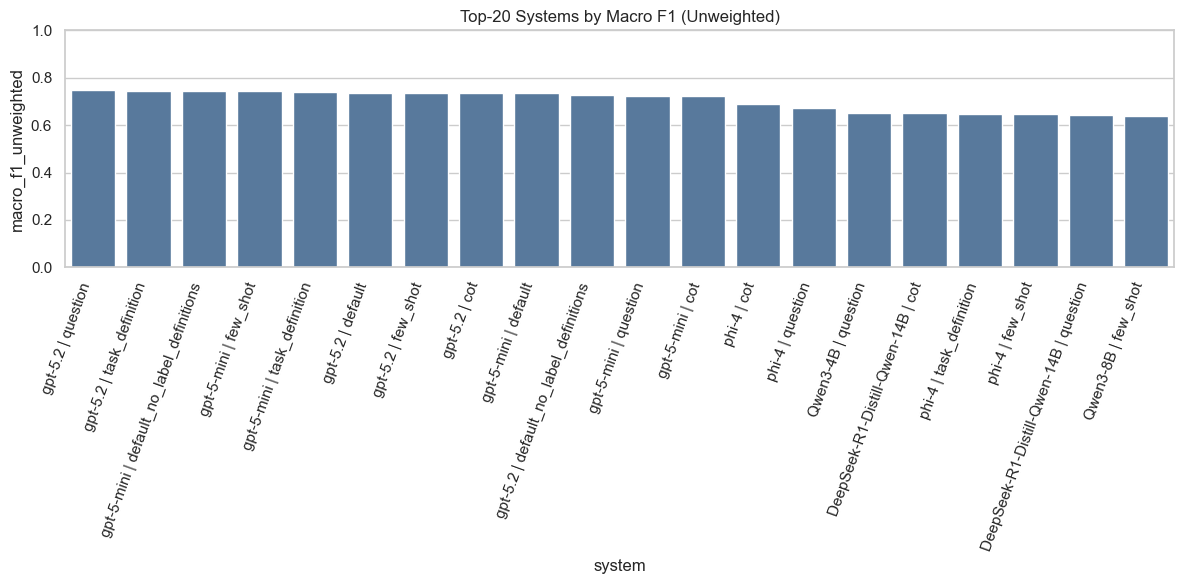

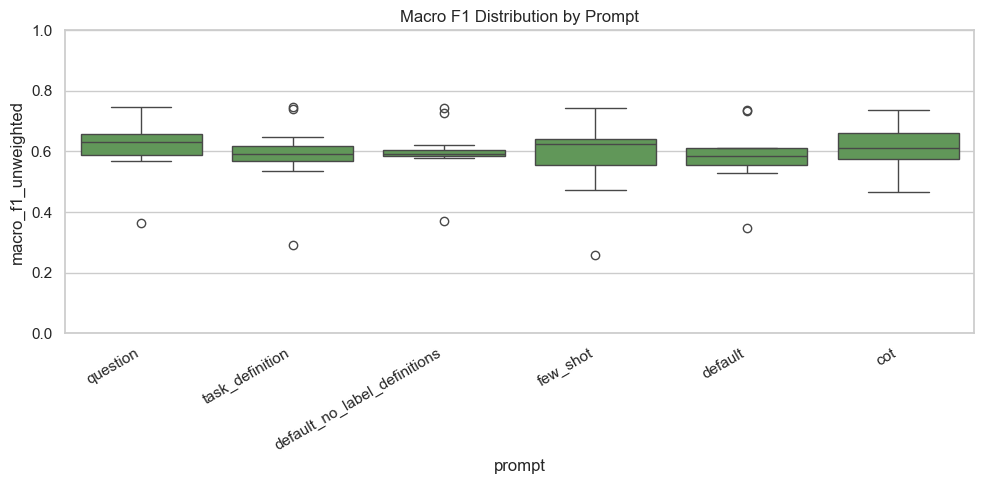

In [189]:
# Simple comparison plots for easier reading
plot_df = metrics_df.copy()

# Plot 1: Top-20 systems by Macro-F1
plot_top = plot_df.sort_values("macro_f1_unweighted", ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_top, x="system", y="macro_f1_unweighted", color="#4C78A8")
plt.title("Top-20 Systems by Macro F1 (Unweighted)")
plt.xticks(rotation=70, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Plot 2: Prompt-level Macro-F1 distribution across models
plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x="prompt", y="macro_f1_unweighted", color="#59A14F")
plt.title("Macro F1 Distribution by Prompt")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


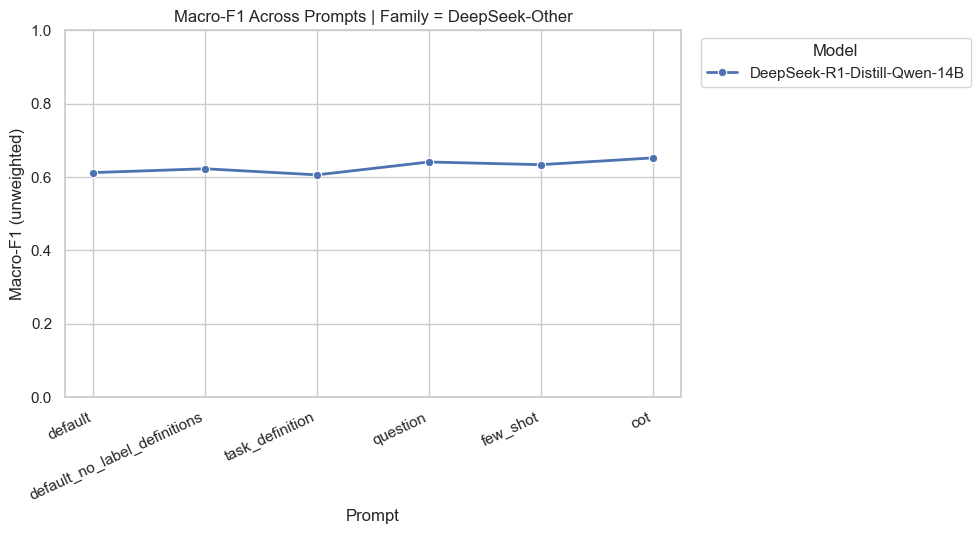

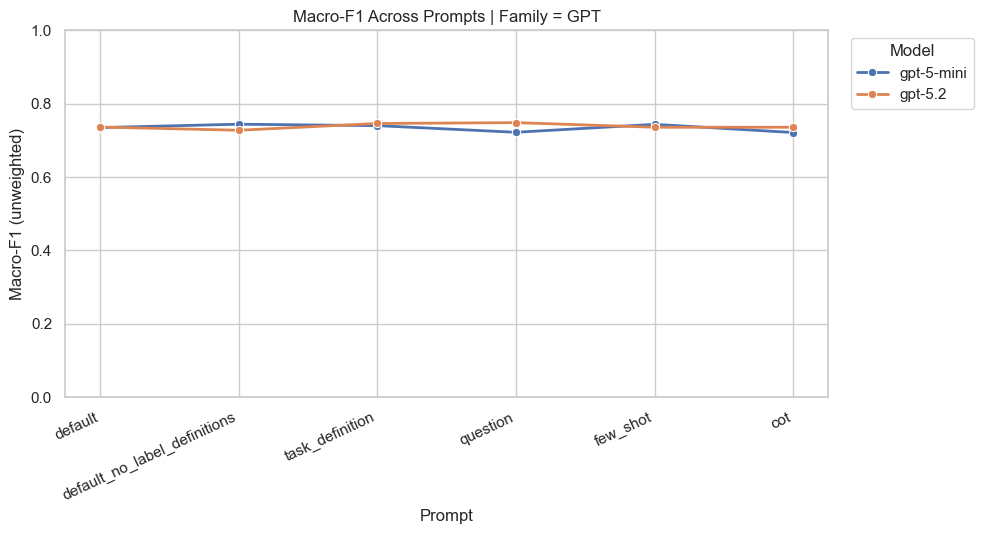

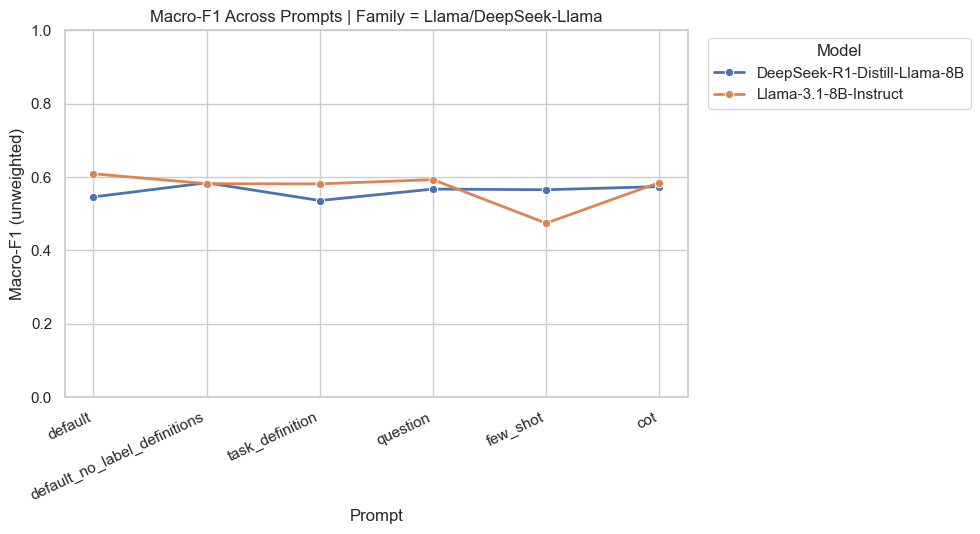

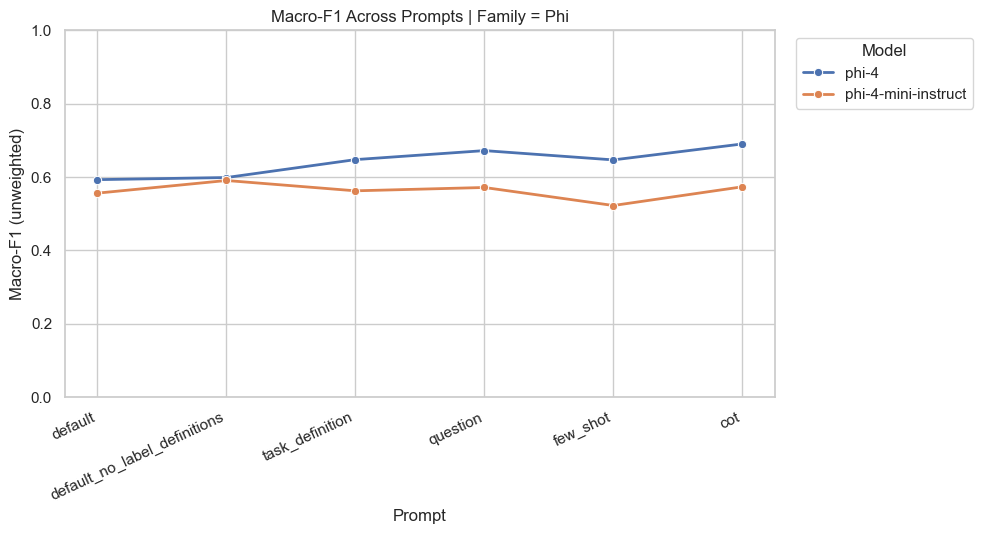

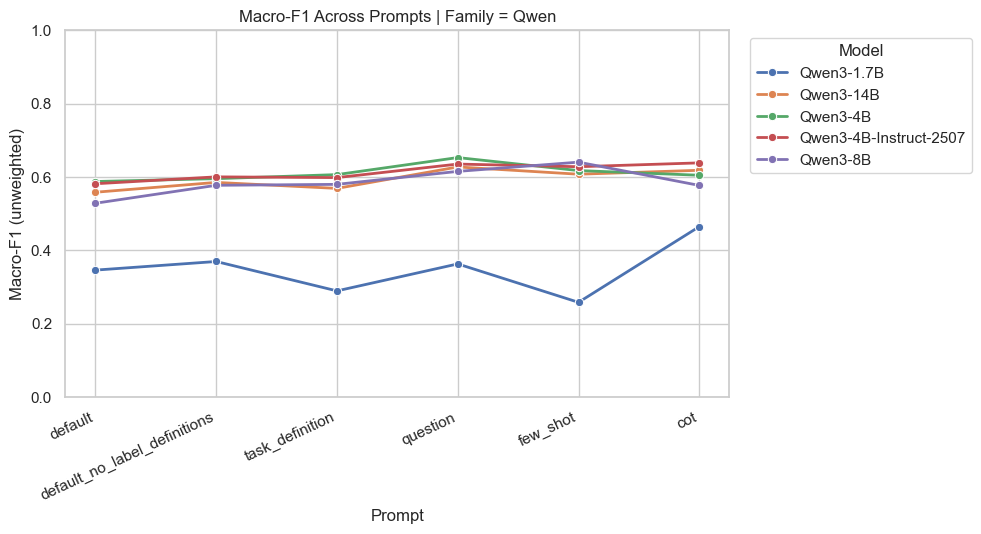

In [191]:
# Family-wise line charts: macro-F1 across prompts

prompt_order = [
    'default',
    'default_no_label_definitions',
    'task_definition',
    'question',
    'few_shot',
    'cot',
]

plot_df = metrics_df.copy()
plot_df['family'] = plot_df['model'].apply(model_family)
plot_df['prompt'] = pd.Categorical(plot_df['prompt'], categories=prompt_order, ordered=True)

for fam in sorted(plot_df['family'].dropna().unique()):
    sub = plot_df[plot_df['family'] == fam].copy().sort_values(['model', 'prompt'])
    if sub.empty:
        continue

    plt.figure(figsize=(10, 5.5))
    sns.lineplot(
        data=sub,
        x='prompt',
        y='macro_f1_unweighted',
        hue='model',
        marker='o',
        linewidth=2,
    )
    plt.title(f'Macro-F1 Across Prompts | Family = {fam}')
    plt.xlabel('Prompt')
    plt.ylabel('Macro-F1 (unweighted)')
    plt.ylim(0, 1)
    plt.xticks(rotation=25, ha='right')
    plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



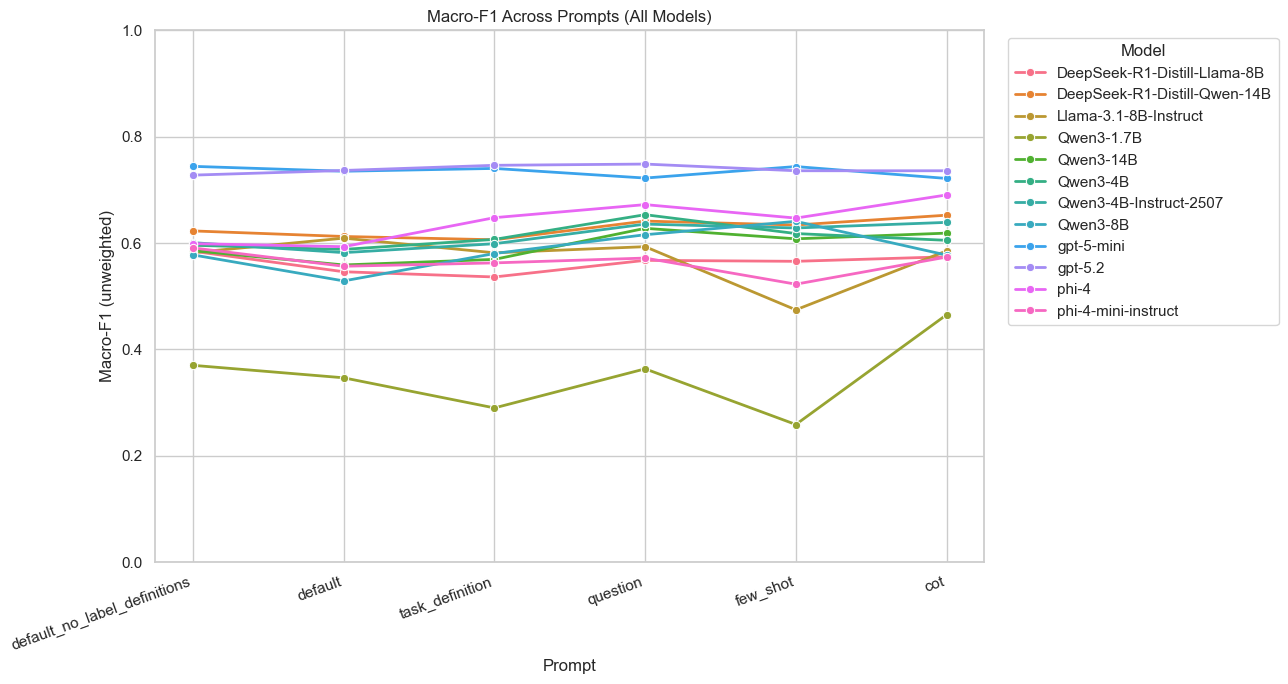

In [192]:
# Single chart: all models across prompts (custom order)
prompt_order = [
    'default_no_label_definitions',
    'default',
    'task_definition',
    'question',
    'few_shot',
    'cot',
]

plot_df = metrics_df.copy()
plot_df['prompt'] = pd.Categorical(plot_df['prompt'], categories=prompt_order, ordered=True)
plot_df = plot_df.sort_values(['model', 'prompt'])

plt.figure(figsize=(13, 7))
sns.lineplot(
    data=plot_df,
    x='prompt',
    y='macro_f1_unweighted',
    hue='model',
    marker='o',
    linewidth=2,
)
plt.title('Macro-F1 Across Prompts (All Models)')
plt.xlabel('Prompt')
plt.ylabel('Macro-F1 (unweighted)')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

